In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 펄서와 우주잡음의 분류(classification) 문제 - KNN이 필요한 모델
- 펄서 별(Pulsar Star) 데이터셋은 지구에 도착한 전파 관측 신호를 바탕으로 치이익- 하는 배경 우주 잡음과 진짜 펄서 별이 보내는 맥박 형태의 전파 신호를 구별하는 이진 분류(Binary Classification) 데이터셋입니다. 자전하며 주기적인 빔을 쏘는 펄서 특유의 물리적 성질 때문에, 일반 잡음과 달리 평균 신호 세기(signal_power)는 낮고 신호의 변동 폭(signal_spread)은 크게 튀는 독특한 데이터 분포를 가집니다.

### 펄서 별(Pulsar Star) 데이터셋 컬럼 명세

| 컬럼명 | 데이터 타입 | 설명 |
| :--- | :--- | :--- |
| **Mean of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **평균값** (신호의 전체적인 세기) |
| **Standard deviation of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **표준편차** (신호 세기의 변동폭) |
| **Excess kurtosis of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **첨도** (신호 분포의 뾰족함 정도) |
| **Skewness of the integrated profile** | Float | 관측된 전파 신호 통합 프로필의 **왜도** (신호 분포의 치우침 정도) |
| **Mean of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **평균값** |
| **Standard deviation of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **표준편차** |
| **Excess kurtosis of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **첨도** |
| **Skewness of the DM-SNR curve** | Float | 분산 측정 신호 대 잡음비(DM-SNR) 곡선의 **왜도** |
| **target_class** | Integer | **클래스 라벨 (0: 우주 잡음 / 1: 진짜 펄서 별)** |

In [3]:
import os
import pandas as pd

base_path = "/Users/hyusoohi5/kdt_0900_khs/python/resource"
file_name = "pulsar_star.csv"

file_path = os.path.join(base_path, file_name)

print(file_path)
print(os.path.exists(file_path))

pulsar_df = pd.read_csv(file_path)

pulsar_df.head()

/Users/hyusoohi5/kdt_0900_khs/python/resource/pulsar_star.csv
True


,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,121.156250,48.372971,0.375485,-0.013165,3.168896,18.399367,7.449874,65.159298,0.0
1,76.968750,36.175557,0.712898,3.388719,2.399666,17.570997,9.414652,102.722975,0.0
2,130.585938,53.229534,0.133408,-0.297242,2.743311,22.362553,8.508364,74.031324,0.0
3,156.398438,48.865942,-0.215989,-0.171294,17.471572,NaN,2.958066,7.197842,0.0
4,84.804688,36.117659,0.825013,3.274125,2.790134,20.618009,8.405008,76.291128,0.0


In [4]:
star_df = pulsar_df[[" Mean of the integrated profile", " Standard deviation of the integrated profile", "target_class"]]
star_df

,Mean of the integrated profile,Standard deviation of the integrated profile,target_class
0,121.156250,48.372971,0.0
1,76.968750,36.175557,0.0
2,130.585938,53.229534,0.0
3,156.398438,48.865942,0.0
4,84.804688,36.117659,0.0
...,...,...,...
12523,124.312500,53.179053,0.0
12524,115.617188,46.784600,0.0
12525,116.031250,43.213846,0.0
12526,135.664062,49.933749,0.0


In [5]:
star_df.columns = ["signal_mean_power", "signal_spread", "target"]
star_df

,signal_mean_power,signal_spread,target
0,121.156250,48.372971,0.0
1,76.968750,36.175557,0.0
2,130.585938,53.229534,0.0
3,156.398438,48.865942,0.0
4,84.804688,36.117659,0.0
...,...,...,...
12523,124.312500,53.179053,0.0
12524,115.617188,46.784600,0.0
12525,116.031250,43.213846,0.0
12526,135.664062,49.933749,0.0


In [6]:
star_df["target"].value_counts()

target
0.0    11375
1.0     1153
Name: count, dtype: int64

### 언더 샘플링(데이터 불균형 해결)

In [7]:
df_0 = star_df[star_df["target"] == 0]
df_1 = star_df[star_df["target"] == 1]

print(len(df_0))
print(len(df_1))

df_0_sampled = df_0.sample(n=len(df_1), random_state=2026)
print(len(df_0_sampled))

11375
1153
1153


In [8]:
print(type(df_1), type(df_0_sampled))

<class 'pandas.DataFrame'> <class 'pandas.DataFrame'>


In [9]:
star_df = pd.concat([df_1, df_0_sampled]).sample(frac=1, random_state=2026).reset_index(drop=True)
star_df.head()

,signal_mean_power,signal_spread,target
0,138.820312,49.549602,0.0
1,25.437500,38.225636,1.0
2,34.023438,32.876299,1.0
3,101.093750,47.496289,0.0
4,101.945312,39.955309,0.0


## 사이킷런 KNN 분류 사이클 실습

### 1단계, 데이터 
- 데이터 정보(info) - 결측치 여부 확인, 데이터 타입 확인(수치형인지, 분류형인지)
- 데이터 기술 통계량(describe) - 4분위수, 이상치
- 데이터 EDA
- 결측치, 이상치 처리, 표준화 또는 정규화

In [32]:
star_df.info()

# signal_mean_power : 수치형
# signal_spread : 수치형
# target : 분류형

<class 'pandas.DataFrame'>
RangeIndex: 2306 entries, 0 to 2305
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   signal_mean_power  2306 non-null   float64
 1   signal_spread      2306 non-null   float64
 2   target             2306 non-null   float64
dtypes: float64(3)
memory usage: 54.2 KB


In [11]:
star_df.describe()

,signal_mean_power,signal_spread,target
count,2306.000000,2306.000000,2306.000000
mean,87.201340,42.994349,0.500000
std,39.140325,8.200844,0.500108
min,5.812500,24.772042,0.000000
25%,54.300781,36.709625,0.000000
50%,96.570312,43.612955,0.500000
75%,118.986328,49.000045,1.000000
max,189.734375,90.250557,1.000000


In [34]:
# 1: 진짜 별
# 신호의 평균세기가 작은 값이 진짜 별
star_df.iloc[star_df["signal_mean_power"].idxmin()]
# 0: 우주 잡음
star_df.iloc[star_df["signal_mean_power"].idxmax()]

signal_mean_power    189.734375
signal_spread         59.578268
target                 0.000000
Name: 383, dtype: float64

In [35]:
star_df.iloc[star_df["signal_spread"].idxmin()]
star_df.iloc[star_df["signal_spread"].idxmax()]

signal_mean_power    128.656250
signal_spread         90.250557
target                 0.000000
Name: 1496, dtype: float64

In [37]:
star_df["target"] = star_df["target"].astype(int)
star_df

,signal_mean_power,signal_spread,target
0,138.820312,49.549602,0
1,25.437500,38.225636,1
2,34.023438,32.876299,1
3,101.093750,47.496289,0
4,101.945312,39.955309,0
...,...,...,...
2301,155.460938,39.429506,0
2302,126.000000,45.366046,0
2303,40.062500,30.721722,1
2304,40.929688,30.200937,1


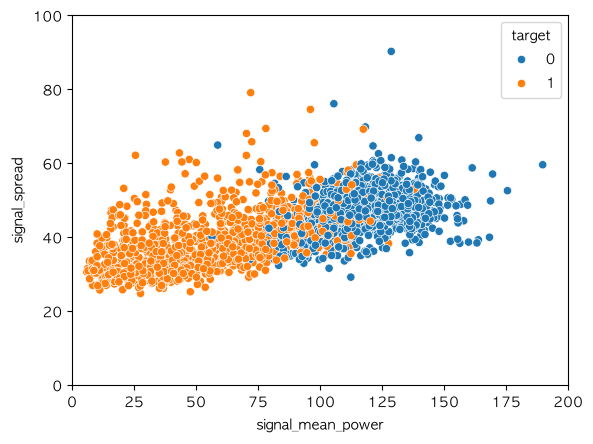

In [89]:
sns.scatterplot(star_df, x="signal_mean_power", y="signal_spread", hue="target")
plt.xlim(0, 200)
plt.ylim(0, 100)

plt.show()

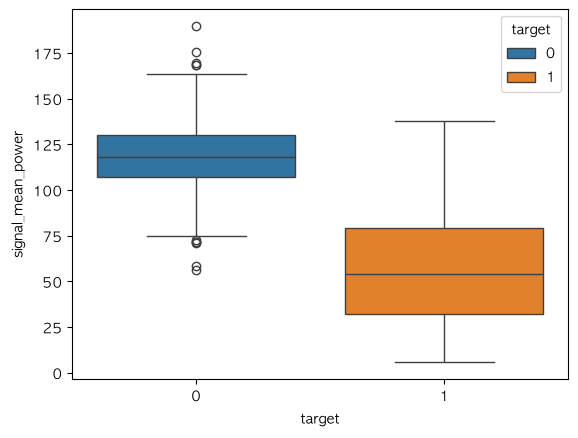

In [41]:
sns.boxplot(star_df, x="target", y="signal_mean_power", hue="target")
plt.show()

### 1단계, 독립 변수와 종속 변수 준비

In [43]:
X = star_df.drop("target", axis=1)
X.head()

,signal_mean_power,signal_spread
0,138.820312,49.549602
1,25.437500,38.225636
2,34.023438,32.876299
3,101.093750,47.496289
4,101.945312,39.955309


In [42]:
y = star_df["target"]
y.head()

0    0
1    1
2    1
3    0
4    0
Name: target, dtype: int64

### 2단계, 데이터 분할

In [12]:
X = star_df.drop("target", axis=1)
y = star_df["target"]

In [13]:
X.head()

,signal_mean_power,signal_spread
0,138.820312,49.549602
1,25.437500,38.225636
2,34.023438,32.876299
3,101.093750,47.496289
4,101.945312,39.955309


In [14]:
y.head()

0    0.0
1    1.0
2    1.0
3    0.0
4    0.0
Name: target, dtype: float64

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=2026
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1844, 2) (462, 2) (1844,) (462,)


In [48]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
# 평균으로부터 얼마나 떨어졌는지를 나타낸 값
X_train_scaled

array([[ 0.860412  ,  0.06373395],
       [-0.04156142, -0.42246395],
       [ 0.83172734, -0.72122983],
       ...,
       [ 0.32894887,  0.84999533],
       [-0.86226162, -1.22677755],
       [ 1.43271095,  0.12325785]], shape=(1844, 2))

### 3단계, 모델 준비

### 하이퍼 파라미터(Hyper Parameter)
- 사람(개발자 또는 분석가)이 필요에 따라 직접 설정하는 파라미터의 값을 의미한다

### 파라미터(Parameter)
- 모델이 학습(fit)을 통해 스스로 찾아내는 값을 의미한다.

In [56]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=5)

### 4단계, 모델 예측

In [62]:
# 표준화
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [65]:
y_pred = kn.predict(X_test_scaled)
y_pred[:10]

array([1, 1, 0, 0, 1, 1, 1, 1, 0, 1])

### 6단계, 모델 평가

In [22]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [23]:
print(f"테스트의 데이터 {(accuracy_score(y_test, y_pred) * 100)}% 을 맞췄다")

테스트의 데이터 89.17748917748918% 을 맞췄다


In [24]:
# 혼동행렬
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[211  20]
 [ 30 201]]


In [25]:
# 상세 평가
classi_report = classification_report(y_test, y_pred)
print(classi_report)

              precision    recall  f1-score   support

         0.0       0.88      0.91      0.89       231
         1.0       0.91      0.87      0.89       231

    accuracy                           0.89       462
   macro avg       0.89      0.89      0.89       462
weighted avg       0.89      0.89      0.89       462



In [67]:
# 1 ~ 20까지 n_neighbors 개수 중 최적의 개수를 찾기
train_scores=[]
test_scores=[]

for k in range(1, 21):
    kn = KNeighborsClassifier(n_neighbors=k)
    kn.fit(X_train_scaled, y_train)

    train_scores.append(kn.score(X_train_scaled, y_train))
    test_scores.append(kn.score(X_test_scaled, y_test))

print(train_scores)
print(test_scores)

[1.0, 0.9235357917570499, 0.9273318872017353, 0.9126898047722343, 0.9181127982646421, 0.9094360086767896, 0.9061822125813449, 0.9072668112798264, 0.9072668112798264, 0.9045553145336226, 0.903470715835141, 0.9023861171366594, 0.9040130151843818, 0.9029284164859002, 0.903470715835141, 0.903470715835141, 0.903470715835141, 0.9013015184381779, 0.9029284164859002, 0.9029284164859002]
[0.8463203463203464, 0.8658008658008658, 0.8722943722943723, 0.8787878787878788, 0.8917748917748918, 0.8917748917748918, 0.8939393939393939, 0.8917748917748918, 0.8939393939393939, 0.8961038961038961, 0.8982683982683982, 0.8939393939393939, 0.8961038961038961, 0.8917748917748918, 0.8961038961038961, 0.9004329004329005, 0.9004329004329005, 0.9004329004329005, 0.8961038961038961, 0.8982683982683982]


In [74]:
train_k = train_scores.index(max(train_scores)) + 1
test_k = test_scores.index(max(test_scores)) + 1

print(f"훈련 데이터셋의 최적의 K의 개수 : {train_k}개")
print(f"테스트 데이터셋의 최적의 K의 개수 : {test_k}개")

훈련 데이터셋의 최적의 K의 개수 : 1개
테스트 데이터셋의 최적의 K의 개수 : 16개


In [101]:
new_data = pd.DataFrame([[50, 60]], columns=["signal_mean_power", "signal_spread"])
new_data_scaled = scaler.transform(new_data)
new_data_scaled

array([[-0.9522996,  2.1075871]])

In [76]:
distances, indexes = kn.kneighbors(new_data_scaled)
distances, indexes

(array([[2.46155809, 2.52123356, 2.54262385, 2.55172036, 2.59510744,
         2.6270417 , 2.65469512, 2.7549523 , 2.80309737, 2.81712525,
         2.8284604 , 2.84375212, 2.84545305, 2.86749686, 2.8676625 ,
         2.87780137, 2.9046318 , 2.91574652, 2.9361534 , 2.94041899]]),
 array([[ 270, 1714, 1405,  330, 1757, 1017,   22,  328,  546,   64,  226,
          557, 1336, 1542,  358,  183,   85,  978,    2, 1729]]))

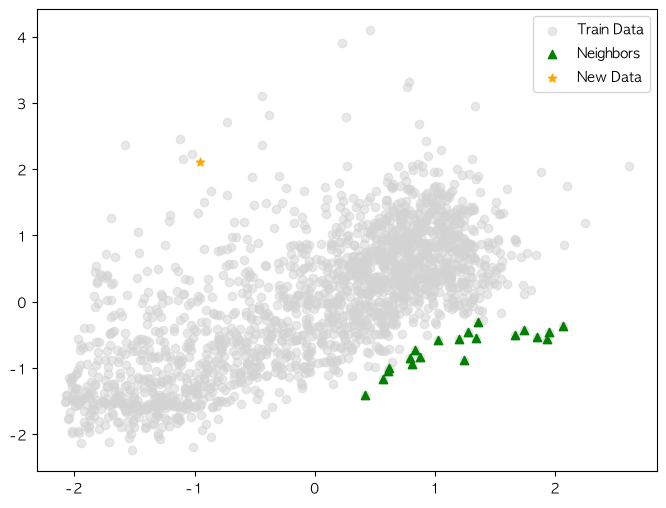

In [102]:
# signal_mean_power, signal_spread
plt.figure(figsize=(8,6))
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c="lightgray", label="Train Data", alpha=0.5)

neighbor_data = X_train_scaled[indexes[0]]
plt.scatter(neighbor_data[:, 0], neighbor_data[:, 1], marker="^", color="green", label="Neighbors")
plt.scatter(new_data_scaled[0, 0], new_data_scaled[0, 1], marker="*", color="orange", label="New Data")
plt.legend()
plt.show()

### 4단계, 모델 평가

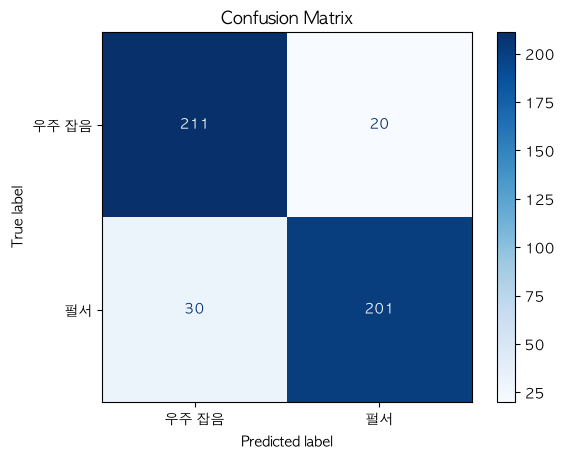

In [96]:
cm = confusion_matrix(y_test, y_pred)
cm

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Noise(0)", "Pulsar(1)"])
display.plot(cmap="Blues")
plt.title("Confusion Matrix")

plt.show()

In [100]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89       231
           1       0.91      0.87      0.89       231

    accuracy                           0.89       462
   macro avg       0.89      0.89      0.89       462
weighted avg       0.89      0.89      0.89       462

